# Compare Metrics for Different pos_weight Values
This notebook analyzes and visualizes the effect of different pos_weight values on model metrics for each endpoint.

In [2]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. Load Endpoint Metrics Data
csv_path = '../results/mt_vs_st.csv'
data = pd.read_csv(csv_path)
data.head()

,ENDPOINT,pos_weight,AUC,ACC,BACC,TN,TP,FP,FN,PR,RC,F1
0,NR-AR,1.0,0.858941,0.974150,0.720588,1.0000,0.4412,0.0000,0.5588,1.0000,0.4412,0.6122
1,NR-Aromatase,1.0,0.825238,0.938356,0.526113,0.9982,0.0541,0.0018,0.9459,0.9673,0.0541,0.1000
2,NR-PPAR-gamma,1.0,0.773203,0.975347,0.500000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
3,SR-HSE,1.0,0.833143,0.938838,0.500000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
4,NR-AR-LBD,1.0,0.864888,0.976574,0.736100,0.9939,0.4783,0.0061,0.5217,0.9875,0.4783,0.5789


In [4]:
# 3. Define Weight Schemes for Endpoints
# Here, pos_weight values are already in the data. If you want to compare custom schemes, define them here.
pos_weights = sorted(data['pos_weight'].unique())
print('pos_weight values:', pos_weights)

pos_weight values: [1.0, 2.0, 3.0, 5.0, 10.0, 15.0, 20.0, 30.0, 40.0, 50.0]


In [5]:
# 4. Apply Weights and Calculate Weighted Metrics
# For demonstration, just group by pos_weight and endpoint, and calculate mean metrics
weighted_metrics = data.groupby(['ENDPOINT', 'pos_weight']).mean().reset_index()
weighted_metrics.head()

,ENDPOINT,pos_weight,AUC,ACC,BACC,TN,TP,FP,FN,PR,RC,F1
0,NR-AR,1.0,0.858941,0.974150,0.720588,1.0000,0.4412,0.0000,0.5588,1.0000,0.4412,0.6122
1,NR-AR,2.0,0.825124,0.975510,0.777272,0.9957,0.5588,0.0043,0.4412,0.9924,0.5588,0.6786
2,NR-AR,3.0,0.820173,0.971429,0.691176,1.0000,0.3824,0.0000,0.6176,1.0000,0.3824,0.5532
3,NR-AR,5.0,0.815306,0.975510,0.749287,0.9986,0.5000,0.0014,0.5000,0.9972,0.5000,0.6538
4,NR-AR,10.0,0.858563,0.971429,0.817110,0.9872,0.6471,0.0128,0.3529,0.9805,0.6471,0.6769


In [6]:
# 5. Compare Weighted Metrics Across Schemes
# Show summary statistics for each endpoint and pos_weight
for metric in ['AUC', 'F1', 'FN', 'TP', 'FP', 'ACC', 'BACC', 'PR', 'RC']:
    print(f"\nMetric: {metric}")
    display(weighted_metrics.pivot(index='ENDPOINT', columns='pos_weight', values=metric))


Metric: AUC


pos_weight,1.0,2.0,3.0,5.0,10.0,15.0,20.0,30.0,40.0,50.0
ENDPOINT,,,,,,,,,,
NR-AR,0.858941,0.825124,0.820173,0.815306,0.858563,0.831837,0.864018,0.834984,0.843333,0.845389
NR-AR-LBD,0.864888,0.876548,0.882411,0.899868,0.903821,0.918182,0.892227,0.882148,0.897958,0.878986
NR-AhR,0.832943,0.821127,0.852900,0.840081,0.821819,0.819312,0.813225,0.812187,0.820840,0.809537
NR-Aromatase,0.825238,0.834626,0.846880,0.813973,0.824053,0.802955,0.792727,0.784327,0.800410,0.803869
NR-ER,0.712570,0.730542,0.724240,0.745735,0.696635,0.692762,0.681771,0.678705,0.695818,0.690863
NR-ER-LBD,0.750000,0.765677,0.795284,0.814496,0.843189,0.866559,0.835121,0.856163,0.818322,0.833832
NR-PPAR-gamma,0.773203,0.772512,0.842516,0.828298,0.857227,0.808452,0.826027,0.845478,0.862066,0.819115
SR-ARE,0.793364,0.816459,0.785745,0.829688,0.805370,0.808590,0.802150,0.808088,0.793004,0.784348
SR-ATAD5,0.793756,0.774080,0.851227,0.856447,0.888521,0.861768,0.840335,0.848918,0.829067,0.855443



Metric: F1


pos_weight,1.0,2.0,3.0,5.0,10.0,15.0,20.0,30.0,40.0,50.0
ENDPOINT,,,,,,,,,,
NR-AR,0.6122,0.6786,0.5532,0.6538,0.6769,0.5432,0.6098,0.3902,0.3623,0.2358
NR-AR-LBD,0.5789,0.6667,0.6977,0.6809,0.6071,0.6552,0.5763,0.4789,0.3838,0.4091
NR-AhR,0.4423,0.5128,0.5556,0.5395,0.4747,0.4305,0.4015,0.3704,0.3777,0.3515
NR-Aromatase,0.1000,0.2326,0.3774,0.4068,0.4884,0.3774,0.3607,0.3600,0.3077,0.2793
NR-ER,0.2245,0.3636,0.3810,0.4204,0.4053,0.3364,0.3099,0.2961,0.2886,0.2757
NR-ER-LBD,0.2439,0.4314,0.4231,0.4643,0.5217,0.4444,0.4040,0.3306,0.3125,0.2537
NR-PPAR-gamma,0.0000,0.1176,0.3000,0.3571,0.3243,0.3571,0.3256,0.2623,0.2727,0.2316
SR-ARE,0.2037,0.3944,0.4744,0.5639,0.4733,0.4501,0.3949,0.4067,0.3742,0.3551
SR-ATAD5,0.0000,0.0000,0.1250,0.3333,0.3462,0.2667,0.4000,0.3590,0.2676,0.2517



Metric: FN


...

pos_weight,1.0,2.0,3.0,5.0,10.0,15.0,20.0,30.0,40.0,50.0
ENDPOINT,,,,,,,,,,
NR-AR,0.720588,0.777272,0.691176,0.749287,0.817110,0.805698,0.851242,0.806579,0.811299,0.758517
NR-AR-LBD,0.736100,0.800560,0.822299,0.841765,0.857444,0.900922,0.855171,0.846080,0.869862,0.855698
NR-AhR,0.653497,0.697708,0.753724,0.754834,0.763189,0.749893,0.758248,0.742409,0.767713,0.738112
NR-Aromatase,0.526113,0.566653,0.629651,0.653021,0.758190,0.725481,0.739710,0.786254,0.754459,0.730891
NR-ER,0.563041,0.612629,0.624936,0.657189,0.680763,0.648808,0.624512,0.615133,0.607473,0.586594
NR-ER-LBD,0.569444,0.649784,0.649035,0.675316,0.738772,0.684714,0.745592,0.729125,0.773120,0.754075
NR-PPAR-gamma,0.500000,0.531250,0.592960,0.650721,0.675652,0.650721,0.702952,0.720774,0.827607,0.790038
SR-ARE,0.554235,0.631980,0.677068,0.783846,0.757902,0.760107,0.710347,0.733519,0.696529,0.675868
SR-ATAD5,0.500000,0.500000,0.533755,0.602720,0.644983,0.621192,0.707398,0.715906,0.759173,0.740476



Metric: PR


pos_weight,1.0,2.0,3.0,5.0,10.0,15.0,20.0,30.0,40.0,50.0
ENDPOINT,,,,,,,,,,
NR-AR,1.0000,0.9924,1.0000,0.9972,0.9805,0.9478,0.9573,0.8839,0.8671,0.7711
NR-AR-LBD,0.9875,0.9877,0.9885,0.9829,0.9682,0.9715,0.9625,0.9402,0.9053,0.9166
NR-AhR,0.9503,0.9397,0.9097,0.8949,0.8300,0.7932,0.7571,0.7277,0.7263,0.7057
NR-Aromatase,0.9673,0.9867,0.9610,0.9466,0.9173,0.8578,0.8377,0.8227,0.7838,0.7596
NR-ER,0.9859,0.9696,0.9053,0.8469,0.7552,0.6553,0.6209,0.5899,0.5736,0.5551
NR-ER-LBD,1.0000,0.9808,0.9761,0.9718,0.9570,0.9523,0.8962,0.8510,0.8241,0.7714
NR-PPAR-gamma,0.0000,1.0000,0.9916,0.9658,0.9406,0.9658,0.9326,0.8953,0.8878,0.8649
SR-ARE,0.8989,0.8684,0.8783,0.8322,0.7429,0.7106,0.6602,0.6642,0.6334,0.6112
SR-ATAD5,0.0000,0.0000,0.9793,0.9930,0.9384,0.8918,0.9305,0.9045,0.8272,0.8162



Metric: RC


pos_weight,1.0,2.0,3.0,5.0,10.0,15.0,20.0,30.0,40.0,50.0
ENDPOINT,,,,,,,,,,
NR-AR,0.4412,0.5588,0.3824,0.5000,0.6471,0.6471,0.7353,0.7059,0.7353,0.7353
NR-AR-LBD,0.4783,0.6087,0.6522,0.6957,0.7391,0.8261,0.7391,0.7391,0.8261,0.7826
NR-AhR,0.3239,0.4225,0.5634,0.5775,0.6620,0.6761,0.7606,0.7746,0.8592,0.8169
NR-Aromatase,0.0541,0.1351,0.2703,0.3243,0.5676,0.5405,0.5946,0.7297,0.7027,0.6757
NR-ER,0.1279,0.2326,0.2791,0.3837,0.5349,0.6279,0.6395,0.7558,0.8372,0.8721
NR-ER-LBD,0.1389,0.3056,0.3056,0.3611,0.5000,0.3889,0.5556,0.5556,0.6944,0.7222
NR-PPAR-gamma,0.0000,0.0625,0.1875,0.3125,0.3750,0.3125,0.4375,0.5000,0.7500,0.6875
SR-ARE,0.1222,0.3111,0.4111,0.7111,0.7889,0.8778,0.8667,0.9444,0.9333,0.9667
SR-ATAD5,0.0000,0.0000,0.0690,0.2069,0.3103,0.2759,0.4483,0.4828,0.6552,0.6207


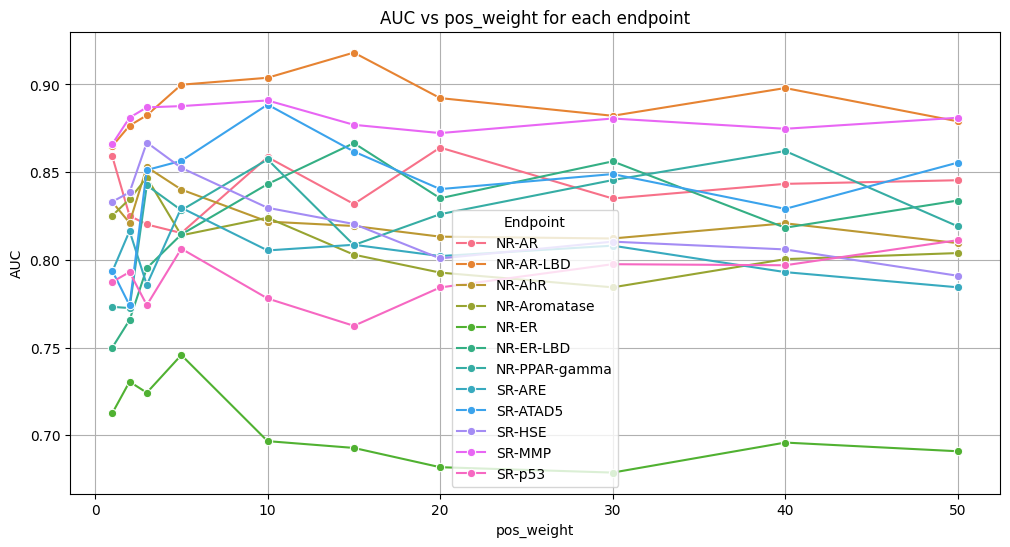

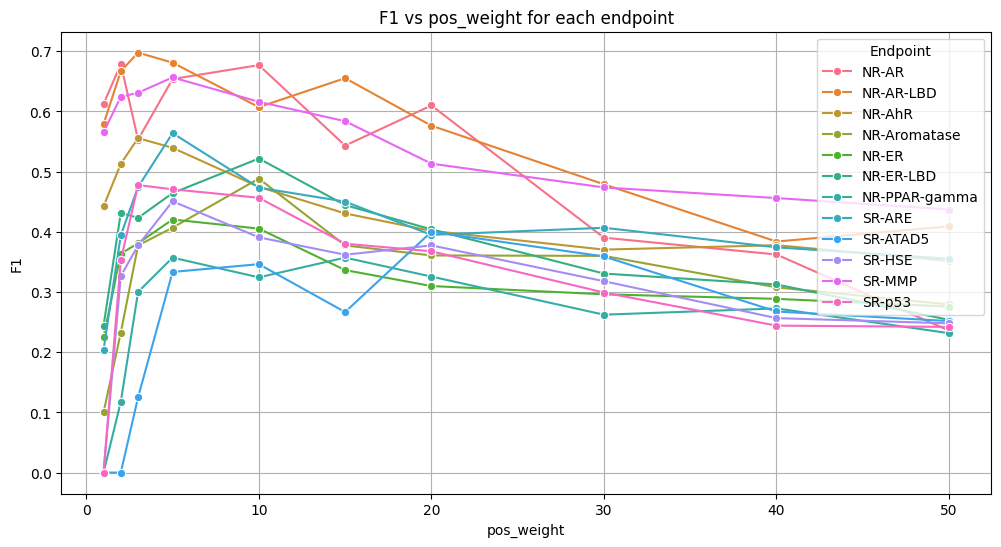

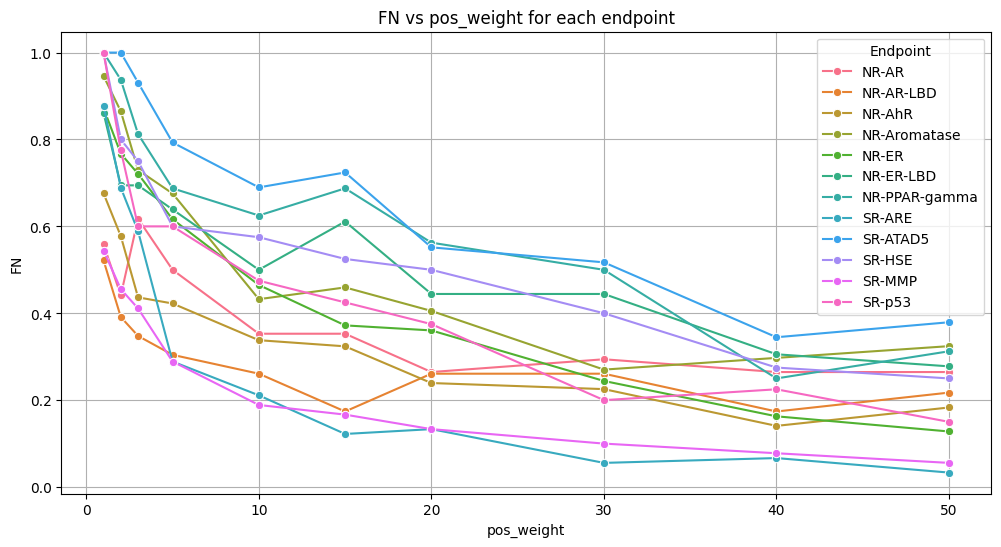

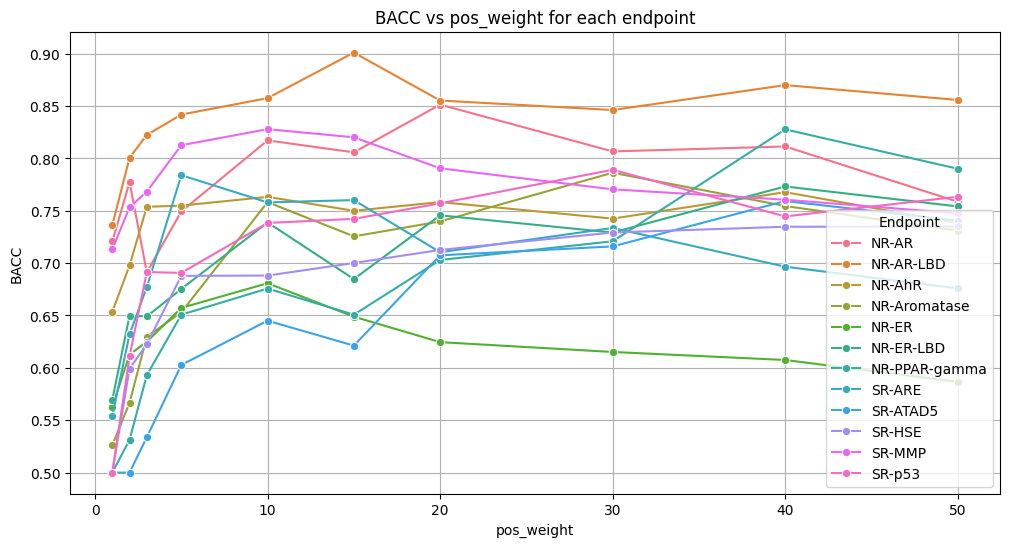

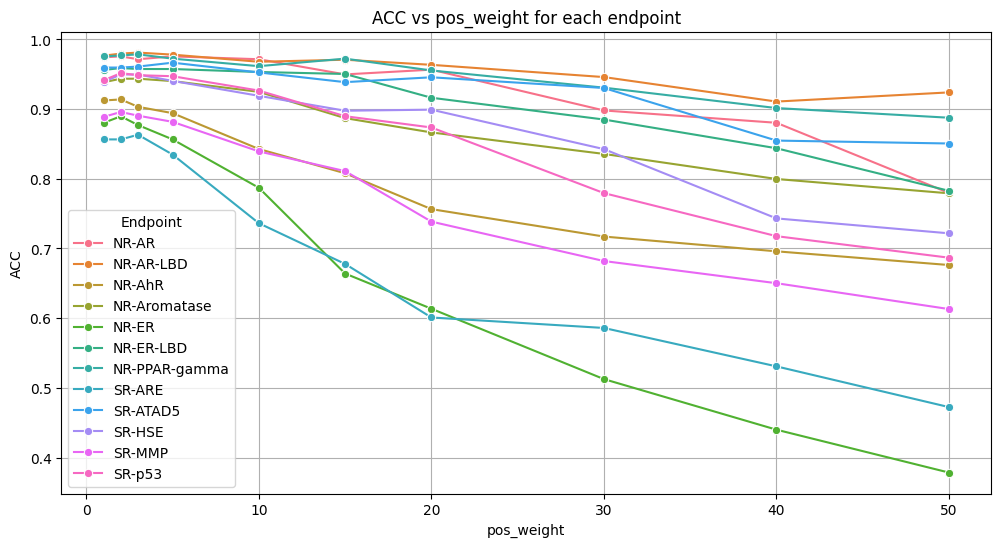

In [9]:
# 6. Visualize Metric Comparisons
# Plot AUC, F1, FN for each endpoint across pos_weight values
metrics_to_plot = ['AUC', 'F1', 'FN', 'BACC', 'ACC']
for metric in metrics_to_plot:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=weighted_metrics, x='pos_weight', y=metric, hue='ENDPOINT', marker='o')
    plt.title(f'{metric} vs pos_weight for each endpoint')
    plt.xlabel('pos_weight')
    plt.ylabel(metric)
    plt.legend(title='Endpoint')
    plt.grid(True)
    plt.show()

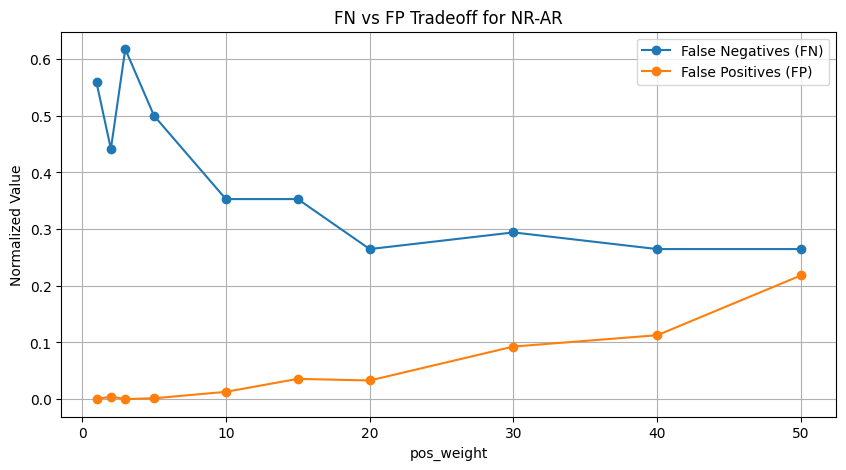

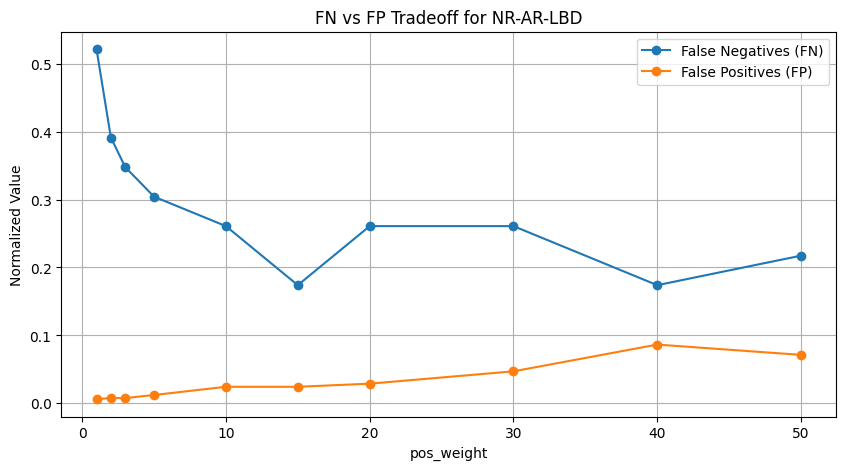

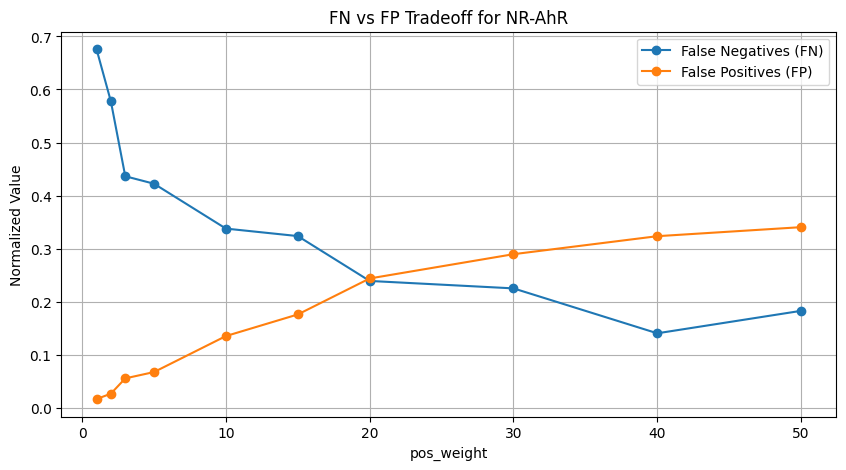

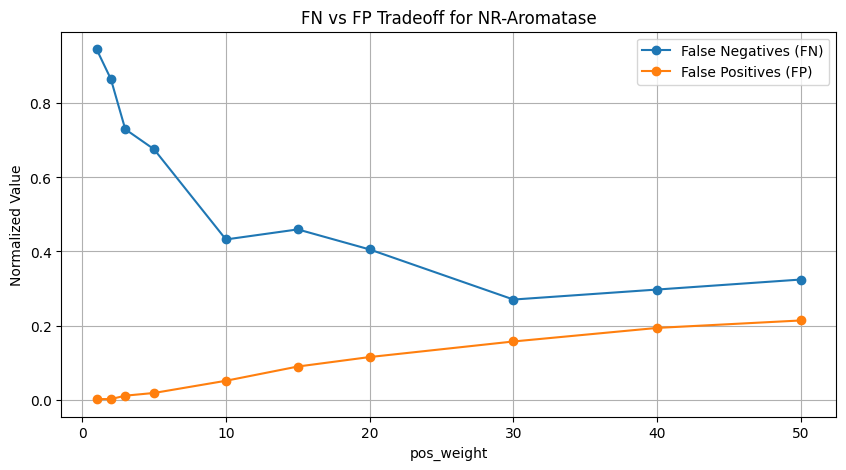

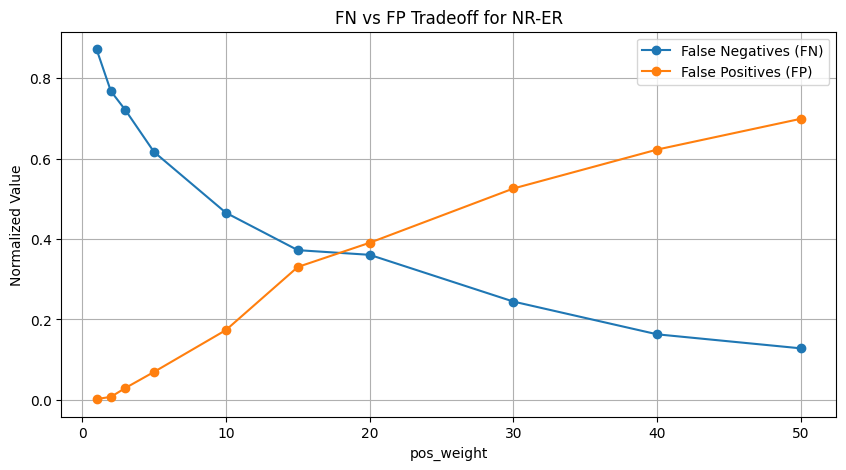

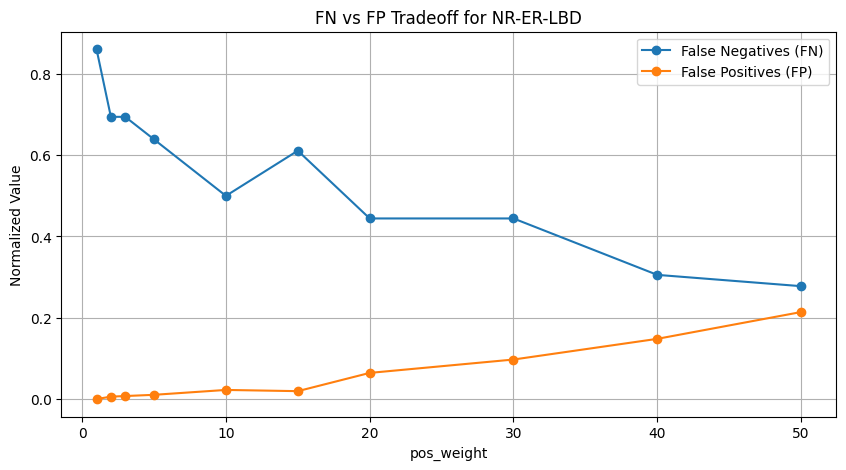

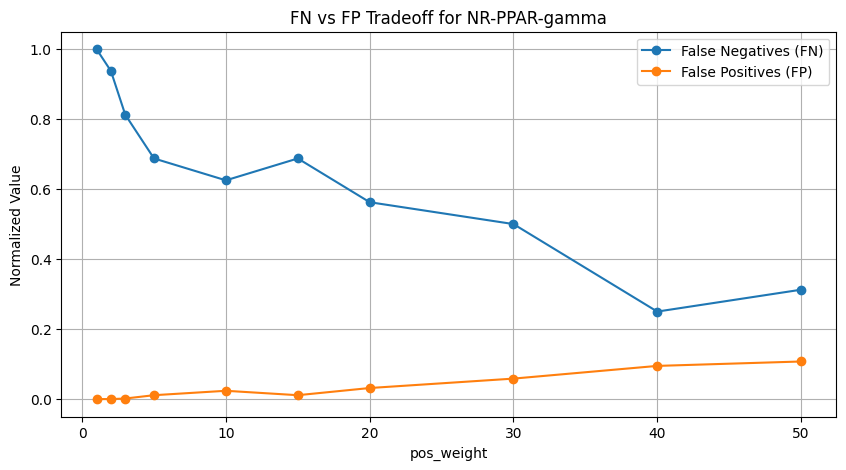

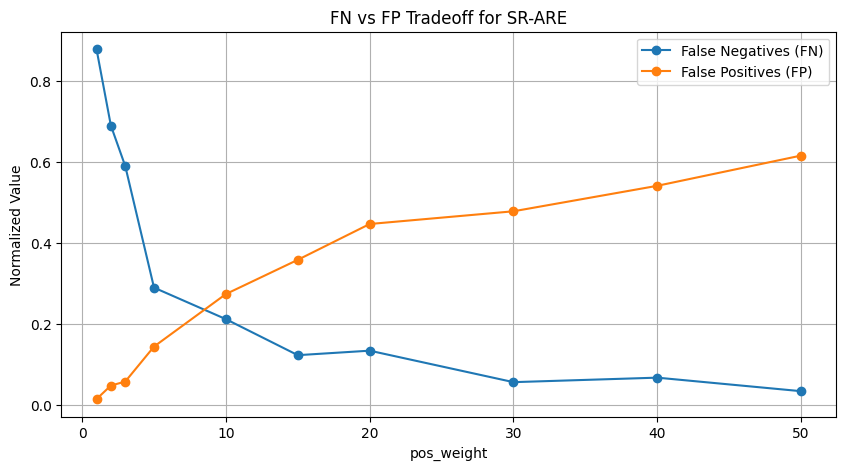

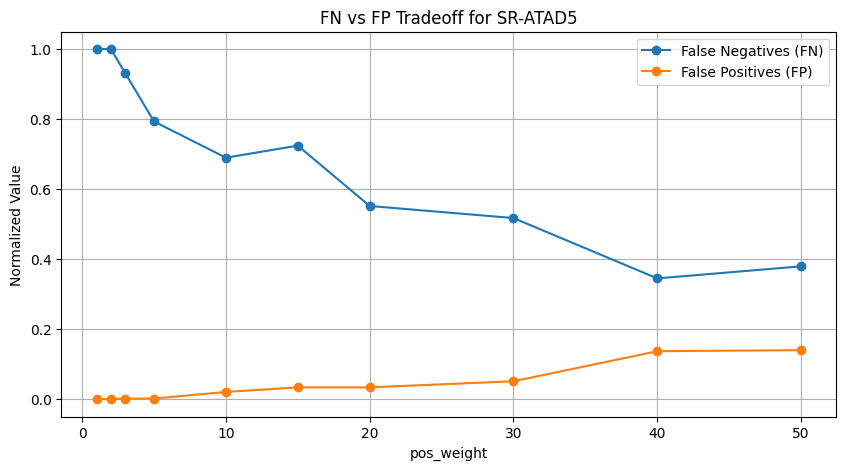

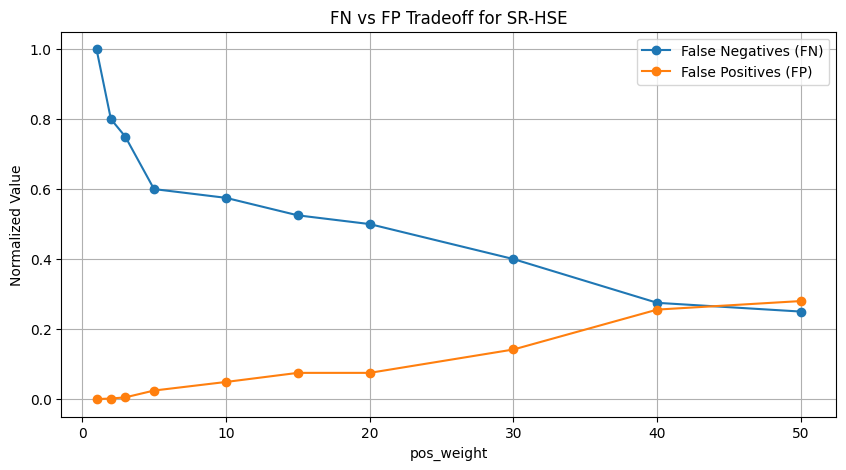

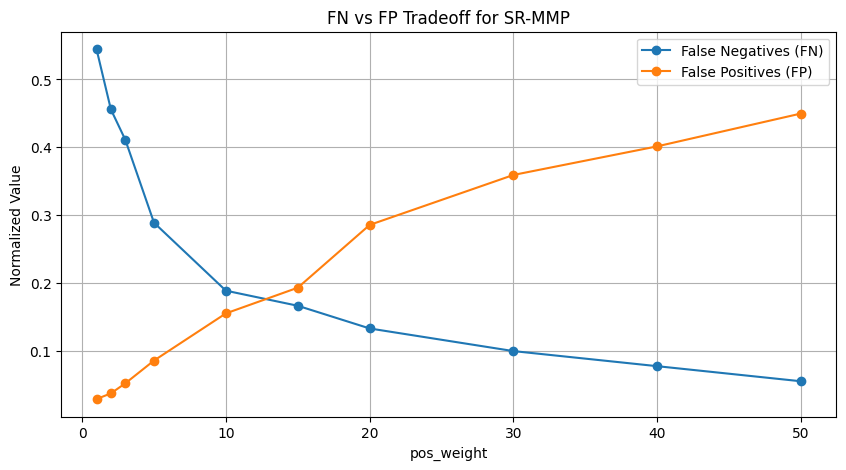

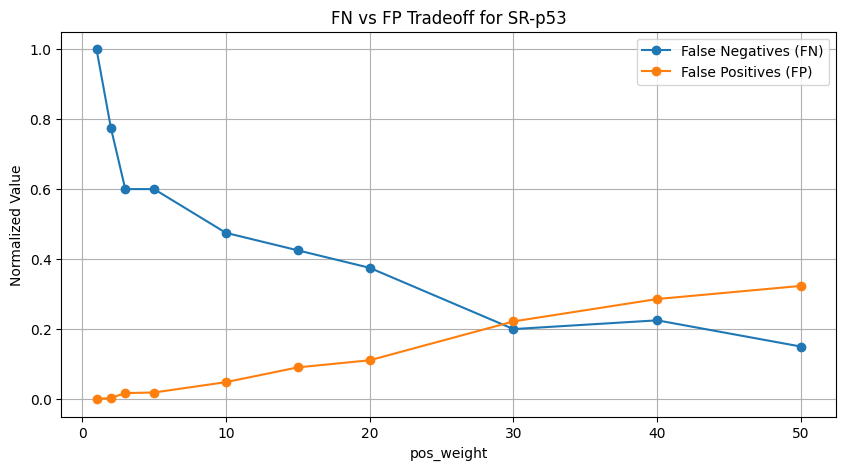

In [10]:
# Plot FN and FP tradeoff for each endpoint
endpoints = weighted_metrics['ENDPOINT'].unique()
for endpoint in endpoints:
    plt.figure(figsize=(10, 5))
    subset = weighted_metrics[weighted_metrics['ENDPOINT'] == endpoint]
    plt.plot(subset['pos_weight'], subset['FN'], marker='o', label='False Negatives (FN)')
    plt.plot(subset['pos_weight'], subset['FP'], marker='o', label='False Positives (FP)')
    plt.title(f'FN vs FP Tradeoff for {endpoint}')
    plt.xlabel('pos_weight')
    plt.ylabel('Normalized Value')
    plt.legend()
    plt.grid(True)
    plt.show()